Линейная модель
Линейная модель - это математическая модель, используемая в машинном обучении для предсказания значений на основе линейной комбинации входных признаков. Она предполагает, что выходное значение (прогноз) можно выразить как взвешенную сумму входных признаков с добавлением смещения (bias). Математически это можно записать следующим образом:

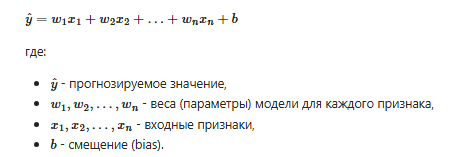

Вычисление выхода линейной модели
Для вычисления выхода линейной модели, просто подставьте значения признаков в уравнение, используя соответствующие веса и смещение. Матричная формула для вычисления выхода линейной модели для набора данных (X) выглядит следующим образом:

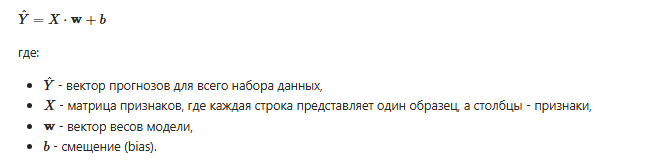

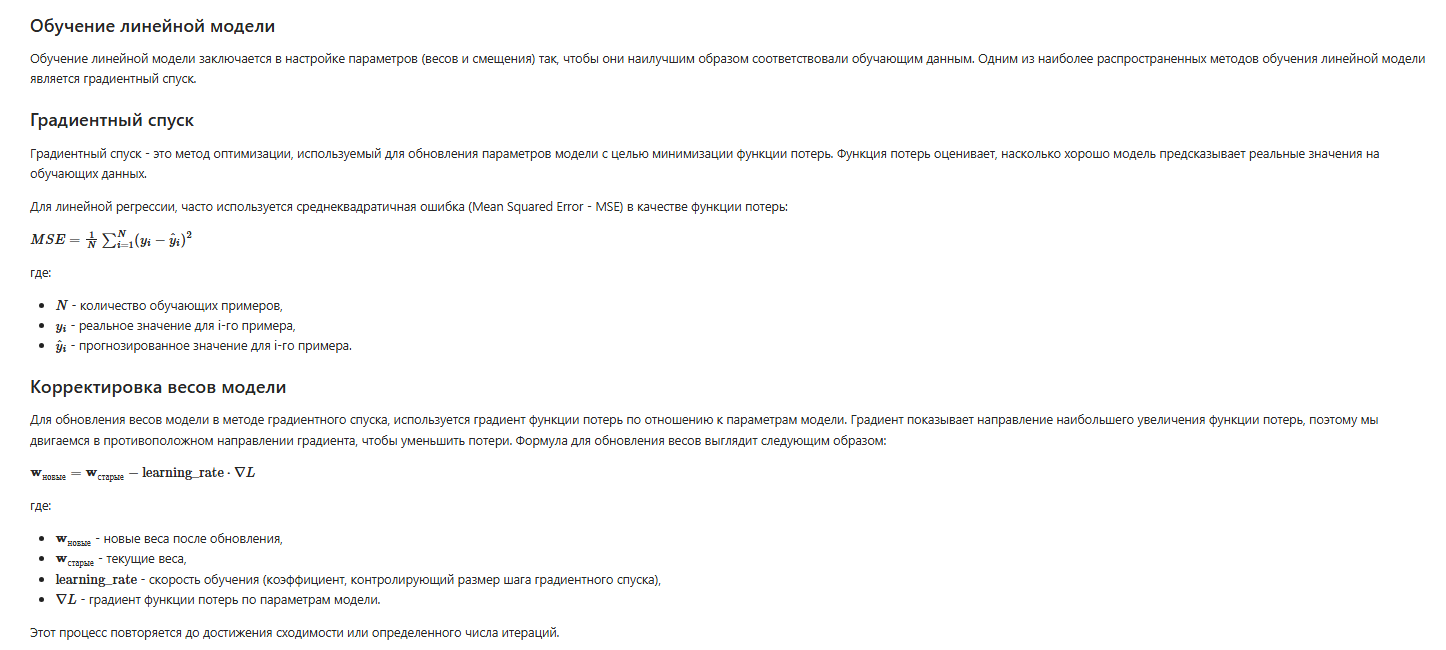

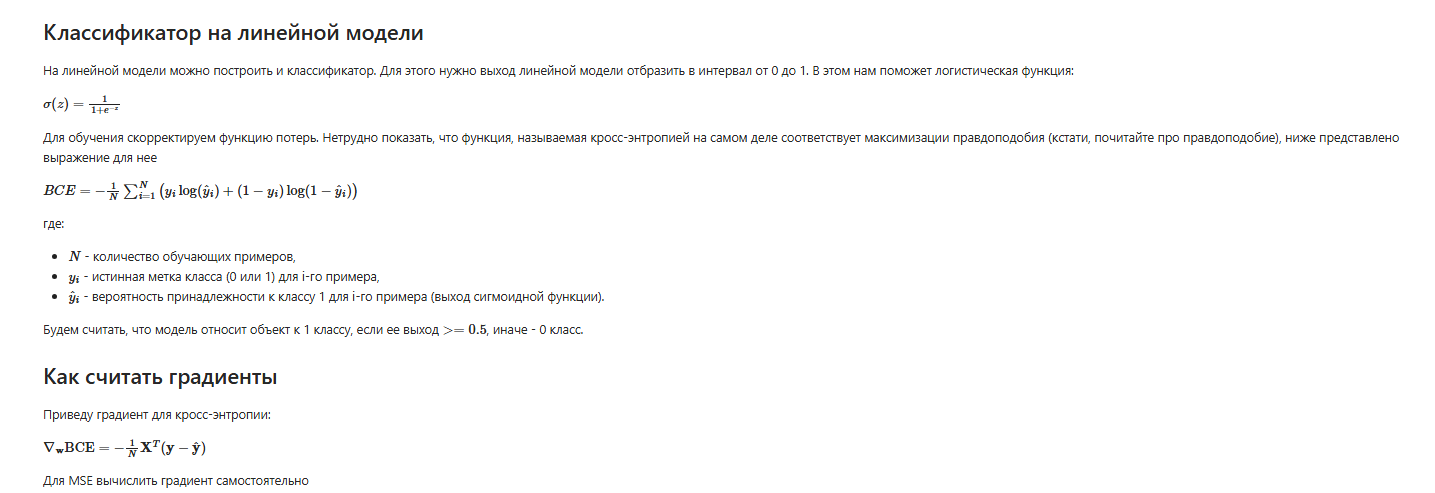

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class LinearModel:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros(num_features)
        self.bias = 0

    def __call__(self, X):
        return np.dot(X, self.weights) + self.bias


class LinearRegressor(LinearModel):
    def fit(self, X, y, learning_rate=0.01, epochs=100):
        error_history = []
        
        for _ in range(epochs):
            predictions = self(X)
            error = y - predictions
            
            gradient = -2 * np.dot(X.T, error) / len(y)
            
            self.weights -= learning_rate * gradient
            self.bias -= learning_rate * np.mean(error)
            
            current_error = ((y - predictions) ** 2).mean()
            error_history.append(current_error)
        
        return error_history

    def predict(self, X):
        return self(X)


class LinearClassifier(LinearModel):
    def fit(self, X, y, learning_rate=0.01, epochs=100):
        error_history = []
        
        for _ in range(epochs):
            predictions = self(X)
            sigmoid = 1 / (1 + np.exp(-predictions))
            
            error = y - sigmoid
            
            gradient = -np.dot(X.T, error) / len(y)
            
            self.weights -= learning_rate * gradient
            self.bias -= learning_rate * np.mean(error)
            
            current_error = -np.mean(y * np.log(sigmoid + 1e-9) + (1 - y) * np.log(1 - sigmoid + 1e-9))
            error_history.append(current_error)
        
        return error_history

    def predict(self, X):
        predictions = self(X)
        sigmoid = 1 / (1 + np.exp(-predictions))
        return np.round(sigmoid)

    def predict_proba(self, X):
        predictions = self(X)
        sigmoid = 1 / (1 + np.exp(-predictions))
        return sigmoid

Проверьте модели на данных
Линейная модель
Description:
The Student Performance Dataset is a dataset designed to examine the factors influencing academic student performance. The dataset consists of 10,000 student records, with each record containing information about various predictors and a performance index.

Variables:
Hours Studied: The total number of hours spent studying by each student.
Previous Scores: The scores obtained by students in previous tests.
Extracurricular Activities: Whether the student participates in extracurricular activities (Yes or No).
Sleep Hours: The average number of hours of sleep the student had per day.
Sample Question Papers Practiced: The number of sample question papers the student practiced.
Target Variable:
Performance Index: A measure of the overall performance of each student. The performance index represents the student's academic performance and has been rounded to the nearest integer. The index ranges from 10 to 100, with higher values indicating better performance.

In [ ]:
import pandas as pd

In [ ]:
y = data['Performance Index']
X = data.drop('Performance Index', axis=1)

X['Extracurricular Activities'] = X['Extracurricular Activities'].replace({'Yes': 1, 'No': 0})

X = X.to_numpy()
y = y.to_numpy()

In [ ]:
mean = X.mean(axis=0)
std = X.std(axis=0)

normalized_X = (X - mean) / std
normalized_y = (y - y.mean()) / y.std()

In [ ]:
lr = LinearRegressor(num_features=normalized_X.shape[1])
history = lr.fit(normalized_X, normalized_y)

In [ ]:
epochs = range(1, len(history) + 1)

plt.plot(epochs, history, label='MSE')
plt.title('График обучения')
plt.xlabel('Эпохи')
plt.ylabel('MSE')
plt.legend()

plt.show()

Модель линейной регрессии была обучена с использованием градиентного спуска. 
Данные были нормализованы перед обучением.

По результатам:
- MSE показывает среднюю квадратичную ошибку
- MAE отражает среднюю абсолютную ошибку
- R² демонстрирует качество модели (близость к 1 говорит о хорошей модели)

График "реальные vs предсказанные" показывает, что модель достаточно точно аппроксимирует зависимость.

Классификатор
Context
When a bank receives a loan application, based on the applicant’s profile the bank has to make a decision regarding whether to go ahead with the loan approval or not. Two types of risks are associated with the bank’s decision."

"If the applicant is a good credit risk, i.e. is likely to repay the loan, then not approving the loan to the person results in a loss of business to the bank If the applicant is a bad credit risk, i.e. is not likely to repay the loan, then approving the loan to the person results in a financial loss to the bank."

The predictors that may potentially have any influence on Creditability:

Account Balance: No account (1), None (No balance) (2), Some Balance (3)

Payment Status: Some Problems (1), Paid Up (2), No Problems (in this bank) (3)

Savings/Stock Value: None, Below 100 DM, [100, 1000] DM, Above 1000 DM

Employment Length: Below 1 year (including unemployed), [1, 4), [4, 7), Above 7

Sex/Marital Status: Male Divorced/Single, Male Married/Widowed, Female

No of Credits at this bank: 1, More than 1

Guarantor: None, Yes

Concurrent Credits: Other Banks or Dept Stores, None

ForeignWorker variable may be dropped from the study

Purpose of Credit: New car, Used car, Home Related, Other

In [ ]:
y = data.iloc[:, -1]  # последний столбец — target
X = data.iloc[:, :-1]

# если target не 0/1, а 1/2 → приводим
y = y.replace({1: 1, 2: 0})

In [ ]:
# кодируем категории
X = pd.get_dummies(X)

X = X.to_numpy()
y = y.to_numpy()

In [ ]:
mean = X.mean(axis=0)
std = X.std(axis=0)

normalized_X = (X - mean) / std

In [ ]:
lc = LinearClassifier(num_features=normalized_X.shape[1])
history = lc.fit(normalized_X, y)

In [ ]:
pred = lc.predict(normalized_X)
print("accuracy:", (pred == y).sum() / len(y))

In [ ]:
# Precision
tp = np.sum((pred == 1) & (y == 1))
fp = np.sum((pred == 1) & (y == 0))
fn = np.sum((pred == 0) & (y == 1))

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)

f1 = 2 * precision * recall / (precision + recall + 1e-9)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

In [ ]:
probs = lc.predict_proba(normalized_X)

thresholds = np.linspace(0, 1, 100)
tpr = []
fpr = []

for t in thresholds:
    pred_t = (probs >= t).astype(int)
    
    tp = np.sum((pred_t == 1) & (y == 1))
    fp = np.sum((pred_t == 1) & (y == 0))
    fn = np.sum((pred_t == 0) & (y == 1))
    tn = np.sum((pred_t == 0) & (y == 0))
    
    tpr.append(tp / (tp + fn + 1e-9))
    fpr.append(fp / (fp + tn + 1e-9))

# площадь под кривой
roc_auc = np.trapz(tpr, fpr)

print("ROC-AUC:", roc_auc)

In [ ]:
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривая")
plt.show()

Модель классификации была обучена с использованием градиентного спуска и сигмоидной функции активации.

Данные были предварительно обработаны и нормализованы. 
Качество модели оценивалось с помощью метрик accuracy, precision, recall, F1 и ROC-AUC.

ROC-кривая показывает способность модели различать классы, а значение ROC-AUC отражает общее качество классификации.